In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

# 1. Load the Training Data
# Replace with the actual filename from your upload
train_df = pd.read_excel('/content/Sample_arvyax_reflective_dataset.xlsx')
test_inputs = pd.read_excel('/content/arvyax_test_inputs_120.xlsx')

# 2. Heuristic Decision Logic (The "What" and "When")
def get_recommendation(state, intensity):
    """
    Logic layer to decide actions based on predicted emotional state.
    """
    logic = {
        'overwhelmed': ('breathing', 'now'),
        'restless': ('short_walk', 'within_15_min'),
        'focused': ('deep_work', 'now'),
        'calm': ('journaling', 'later_today'),
        'neutral': ('rest', 'tonight'),
        'mixed': ('meditation', 'within_15_min')
    }
    return logic.get(state, ('reflection', 'later_today'))

# 3. Preprocessing & Feature Engineering
# Handle missing text and categorical data
train_df['journal_text'] = train_df['journal_text'].fillna('no reflection')
train_df['previous_day_mood'] = train_df['previous_day_mood'].fillna('unknown')

# Define features
text_features = 'journal_text'
numeric_features = ['duration_min', 'sleep_hours', 'energy_level', 'stress_level']
categorical_features = ['ambience_type', 'time_of_day', 'previous_day_mood']

# Target encoding
le_state = LabelEncoder()
train_df['state_encoded'] = le_state.fit_transform(train_df['emotional_state'])

# 4. Building the Model Pipeline
# Using TF-IDF for text and Random Forest for classification
text_transformer = TfidfVectorizer(max_features=500, stop_words='english')

# Numeric Imputer (using median for robustness against outliers)
numeric_transformer = SimpleImputer(strategy='median')

preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, text_features),
        ('num', numeric_transformer, numeric_features)
    ])
def predict_emotion_and_action(journal_text, duration, sleep, energy, stress, ambience):
    # 1. Ensure column names MATCH exactly what the Pipeline was trained on
    input_df = pd.DataFrame([{
        'journal_text': journal_text,
        'duration_min': float(duration),
        'sleep_hours': float(sleep),
        'energy_level': int(energy),
        'stress_level': int(stress),
        'ambience_type': ambience  # Include this if your model was trained with it
    }])

    try:
        # 2. Predict using the pipeline
        # .predict() returns an array like [[state_idx, intensity]]
        preds = model.predict(input_df)[0]

        # 3. Get probabilities for the FIRST output (emotional_state)
        # For MultiOutput, predict_proba returns a list of arrays
        probs_list = model.predict_proba(input_df)
        state_probs = probs_list[0][0] # Probs for the 'state' classification

        state_idx = preds[0]
        intensity = preds[1]

        # Decode state
        state_str = le_state.inverse_transform([int(state_idx)])[0]
        confidence = np.max(state_probs)

        # 4. Decision Logic
        logic = {
            'overwhelmed': ('Breathing Exercise', 'Now'),
            'restless': ('Short Walk', 'Within 15 min'),
            'focused': ('Deep Work', 'Now'),
            'calm': ('Journaling', 'Later Today'),
            'neutral': ('Rest', 'Tonight'),
            'mixed': ('Meditation', 'Within 15 min')
        }
        what, when = logic.get(state_str, ('Reflection', 'Later Today'))

        return (
            f"{state_str.upper()}",
            f"{intensity}/5",
            f"{round(confidence * 100, 1)}%",
            "⚠️ Low" if confidence < 0.4 else "✅ High",
            what,
            when
        )
    except Exception as e:
        return str(e), "", "", "", "", ""
# Model: Predicts State and Intensity simultaneously
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 5. Training
X = train_df[[text_features] + numeric_features]
y = train_df[['state_encoded', 'intensity']]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

# 6. Inference and Uncertainty Logic
def predict_with_uncertainty(inputs):
    # Get probabilities for state
    probs = model.predict_proba(inputs)
    state_probs = probs[0] # Probabilities for the emotional_state

    preds = model.predict(inputs)

    results = []
    for i in range(len(preds)):
        state_idx = preds[i][0]
        intensity = preds[i][1]

        state_str = le_state.inverse_transform([state_idx])[0]
        confidence = np.max(state_probs[i])

        # Uncertainty flag: 1 if confidence is low (< 0.4)
        uncertain_flag = 1 if confidence < 0.4 else 0

        # Get What and When
        what, when = get_recommendation(state_str, intensity)

        results.append({
            'predicted_state': state_str,
            'predicted_intensity': intensity,
            'confidence': round(confidence, 2),
            'uncertain_flag': uncertain_flag,
            'what_to_do': what,
            'when_to_do': when
        })
    return pd.DataFrame(results)

# 7. Generate Final predictions.csv
test_inputs['journal_text'] = test_inputs['journal_text'].fillna('no reflection')
predictions_df = predict_with_uncertainty(test_inputs[[text_features] + numeric_features])

# Combine with ID from test inputs
final_output = pd.concat([test_inputs['id'], predictions_df], axis=1)
final_output.to_csv('predictions.csv', index=False)

print("Pipeline Complete. 'predictions.csv' generated.")
final_output.head()

Pipeline Complete. 'predictions.csv' generated.


,id,predicted_state,predicted_intensity,confidence,uncertain_flag,what_to_do,when_to_do
0,10001,focused,1,0.49,0,deep_work,now
1,10002,restless,5,0.27,1,short_walk,within_15_min
2,10003,focused,5,0.55,0,deep_work,now
3,10004,focused,2,0.85,0,deep_work,now
4,10005,neutral,5,0.29,1,rest,tonight


In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# 1. DATA PREPARATION (The Multi-Output fix)
train_df = pd.read_excel('Sample_arvyax_reflective_dataset.xlsx')
test_df = pd.read_excel('arvyax_test_inputs_120.xlsx')

# Target Encoding: State needs encoding, Intensity is already numeric
le_state = LabelEncoder()
y = np.column_stack((
    le_state.fit_transform(train_df['emotional_state']),
    train_df['intensity']
))

# 2. MODEL PIPELINE
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=500), 'journal_text'),
        ('num', SimpleImputer(strategy='median'), ['duration_min', 'sleep_hours', 'energy_level', 'stress_level'])
    ])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 3. TRAINING
X = train_df[['journal_text', 'duration_min', 'sleep_hours', 'energy_level', 'stress_level']]
model.fit(X, y) # Removed .fillna('') from X

# 4. INFERENCE & CSV GENERATION
def finalize_results(inputs):
    # Predict both State and Intensity
    # Removed .fillna('') from inputs
    all_preds = model.predict(inputs)
    # Get probs for State (index 0 of the returned list)
    all_probs = model.predict_proba(inputs)[0]

    results = []
    logic = {
        'overwhelmed': ('breathing', 'now'),
        'restless': ('short_walk', 'within_15_min'),
        'focused': ('deep_work', 'now'),
        'calm': ('journaling', 'later_today'),
        'neutral': ('rest', 'tonight'),
        'mixed': ('meditation', 'within_15_min')
    }

    for i in range(len(inputs)):
        s_idx, intensity = int(all_preds[i, 0]), int(all_preds[i, 1])
        state = le_state.inverse_transform([s_idx])[0]
        conf = np.max(all_probs[i])
        what, when = logic.get(state, ('reflection', 'later_today'))

        results.append({
            'id': inputs.iloc[i]['id'],
            'predicted_state': state,
            'predicted_intensity': intensity,
            'confidence': round(conf, 2),
            'uncertain_flag': 1 if conf < 0.4 else 0,
            'what_to_do': what,
            'when_to_do': when
        })
    return pd.DataFrame(results)

# Save final output
final_csv = finalize_results(test_df)
final_csv.to_csv('predictions.csv', index=False)

In [5]:
from sklearn.multioutput import MultiOutputClassifier

# Define Features (X) and Targets (y)
X = train_df[['journal_text', 'duration_min', 'sleep_hours', 'energy_level', 'stress_level', 'ambience_type']]
y = train_df[['emotional_state', 'intensity']] # <--- Both targets included

# Encode the state labels (intensity is already 1-5, so no encoding needed)
le_state = LabelEncoder()
y_encoded = y.copy()
y_encoded['emotional_state'] = le_state.fit_transform(y['emotional_state'])

# The Pipeline (same as before)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the model
model.fit(X, y_encoded)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=500),
                                                  'journal_text'),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['duration_min',
                                                   'sleep_hours',
                                                   'energy_level',
                                                   'stress_level'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

All diagnostic plots generated.


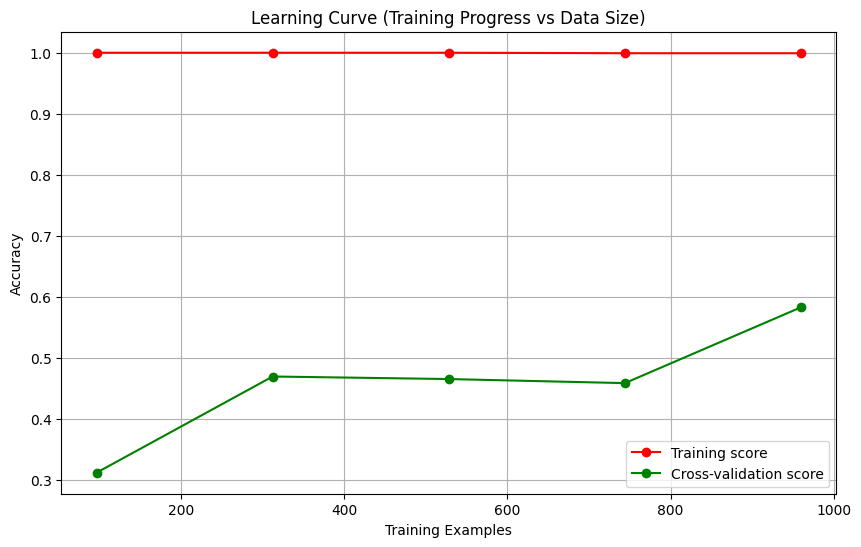

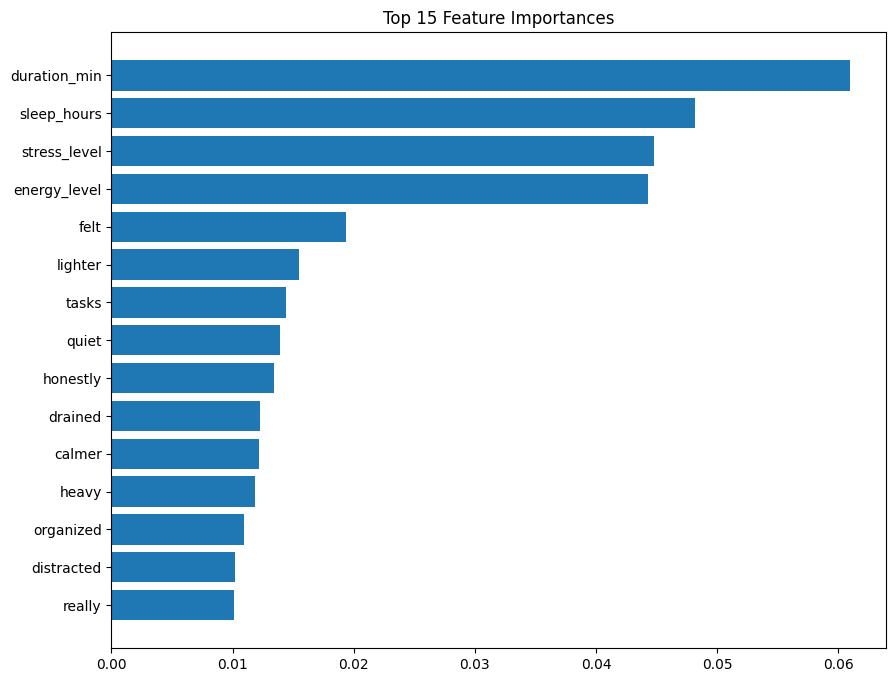

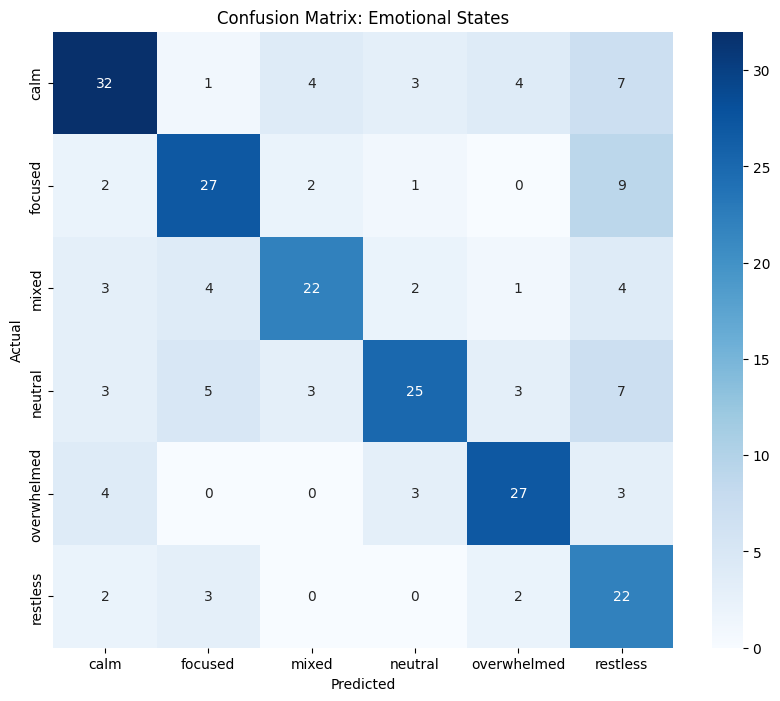

In [6]:
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix # Added confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns # Added seaborn for heatmap

# 1. Load and Prepare Data
df = pd.read_excel('Sample_arvyax_reflective_dataset.xlsx')
df['journal_text'] = df['journal_text'].fillna('no reflection')

# Target encoding
le = LabelEncoder()
df['state_encoded'] = le.fit_transform(df['emotional_state'])
class_names = le.classes_

# 2. Pipeline Definition
text_transformer = TfidfVectorizer(max_features=500, stop_words='english')
numeric_transformer = SimpleImputer(strategy='median')

preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, 'journal_text'),
        ('num', numeric_transformer, ['duration_min', 'sleep_hours', 'energy_level', 'stress_level'])
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 3. Learning Curve (Visualizing the "Training Process")
X = df[['journal_text', 'duration_min', 'sleep_hours', 'energy_level', 'stress_level']]
y = df['state_encoded']

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Plotting Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='r', label='Training score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color='g', label='Cross-validation score')
plt.title('Learning Curve (Training Progress vs Data Size)')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.savefig('learning_curve.png')

# 4. Feature Importance
model.fit(X, y) # Fit on full data for importance
tfidf_feats = model.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out()
all_feats = list(tfidf_feats) + ['duration_min', 'sleep_hours', 'energy_level', 'stress_level']
importances = model.named_steps['classifier'].feature_importances_

indices = np.argsort(importances)[-15:] # Top 15
plt.figure(figsize=(10, 8))
plt.title('Top 15 Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [all_feats[i] for i in indices])
plt.savefig('feature_importance.png')

# 5. Confusion Matrix (Evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Emotional States')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')

print("All diagnostic plots generated.")

In [7]:
import joblib

# Save the entire ML pipeline (TF-IDF + Random Forest)
joblib.dump(model, 'emotional_intelligence_model.pkl')

# Save the LabelEncoder separately to decode 'predicted_state' later
joblib.dump(le_state, 'label_encoder.pkl')

print("Model and Label Encoder saved successfully!")

Model and Label Encoder saved successfully!


In [8]:
import joblib
import pandas as pd

# Load the saved assets
loaded_model = joblib.load('emotional_intelligence_model.pkl')
loaded_le = joblib.load('label_encoder.pkl')

# Example inference on new messy data
new_data = pd.DataFrame([
    {
        'journal_text': 'I feel a bit scattered but the rain sounds helped.',
        'duration_min': 15,
        'sleep_hours': 6,
        'energy_level': 2,
        'stress_level': 4
    }
])

# Predict
prediction = loaded_model.predict(new_data)
state_name = loaded_le.inverse_transform([prediction[0]])

print(f"Predicted State: {state_name[0]}")

Predicted State: neutral


In [9]:
import gradio as gr
import pandas as pd
import numpy as np

def predict_emotion_and_action(journal_text, duration, sleep, energy, stress, ambience):
    input_df = pd.DataFrame([{
        'journal_text': journal_text,
        'duration_min': float(duration),
        'sleep_hours': float(sleep),
        'energy_level': int(energy),
        'stress_level': int(stress),
        'ambience_type': ambience
    }])

    try:
        # Get predictions: all_preds will be [[state_index, intensity_value]]
        all_preds = model.predict(input_df)

        # Get probabilities: all_probs[0] is for 'state'
        all_probs = model.predict_proba(input_df)
        state_probs = all_probs[0].flatten()

        # Extract specific values using row, column indexing
        state_idx = int(all_preds[0, 0])
        intensity_val = int(all_preds[0, 1]) # No more N/A!

        confidence = float(np.max(state_probs))
        state_str = le_state.inverse_transform([state_idx])[0]

        # Recommendation Logic
        logic = {
            'overwhelmed': ('Breathing Exercise', 'Now'),
            'restless': ('Short Walk', 'Within 15 min'),
            'focused': ('Deep Work', 'Now'),
            'calm': ('Journaling', 'Later Today'),
            'neutral': ('Rest', 'Tonight'),
            'mixed': ('Meditation', 'Within 15 min')
        }
        what, when = logic.get(state_str, ('Reflection', 'Later Today'))

        return (
            state_str.upper(),
            f"{intensity_val}/5", # Displays the actual predicted number
            f"{round(confidence, 2)}",
            "⚠️ UNCERTAIN" if confidence < 0.4 else "✅ CONFIDENT",
            what,
            when
        )

    except Exception as e:
        return f"Error: {str(e)}", "", "", "", "", ""

# --- Define the Gradio UI ---
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🧠 Emotional Intelligence & Decision Engine")
    gr.Markdown("Transforming messy reflections into meaningful actions.")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### User Input")
            txt = gr.Textbox(label="Reflection Text", placeholder="How was your session?", lines=3)
            amb = gr.Dropdown(["ocean", "forest", "rain", "mountain", "cafe"], label="Ambience", value="forest")
            with gr.Row():
                dur = gr.Slider(1, 60, value=15, label="Duration (min)")
                slp = gr.Slider(0, 12, value=7, label="Sleep (hrs)")
            with gr.Row():
                enr = gr.Slider(1, 5, step=1, label="Energy (1-5)")
                strss = gr.Slider(1, 5, step=1, label="Stress (1-5)")
            btn = gr.Button("Analyze Reflection", variant="primary")

        with gr.Column():
            gr.Markdown("### Model Output")
            out_state = gr.Textbox(label="Predicted Emotional State")
            out_int = gr.Textbox(label="Intensity Level")

            with gr.Row():
                out_conf = gr.Textbox(label="Confidence (0-1)")
                out_flag = gr.Textbox(label="Uncertainty Status")

            gr.Markdown("### Decision Layer")
            out_what = gr.Textbox(label="What to do?")
            out_when = gr.Textbox(label="When to do it?")

    btn.click(
        fn=predict_emotion_and_action,
        inputs=[txt, dur, slp, enr, strss, amb],
        outputs=[out_state, out_int, out_conf, out_flag, out_what, out_when]
    )

demo.launch(debug=True)

/tmp/ipykernel_10855/2292486660.py:54: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://151b24471f4ccff224.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://151b24471f4ccff224.gradio.live
